# data clean

In [4]:
import pandas as pd
from sklearn.impute import SimpleImputer


In [13]:
df = pd.read_csv(r'D:\python_data_script\data_clean_scripts\Zomato Dataset.csv')
df.head(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [ ]:
# IQR detector for multiple_deliveries
Q1 = df['Time_taken (min)'].quantile(0.25)
Q3 = df['Time_taken (min)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = ((df['Time_taken (min)'] < lower_bound) | (df['Time_taken (min)'] > upper_bound))
print(f"IQR method identified {outliers_iqr.sum()} outliers in Time_taken (min)")

IQR method identified 270 outliers in Time_taken (min)


In [ ]:
# IQR detector for multiple_deliveries
Q1 = df['multiple_deliveries'].quantile(0.25)
Q3 = df['multiple_deliveries'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = ((df['multiple_deliveries'] < lower_bound) | (df['multiple_deliveries'] > upper_bound))
print(f"IQR method identified {outliers_iqr.sum()} outliers in multiple_deliveries")

IQR method identified 361 outliers in multiple_deliveries


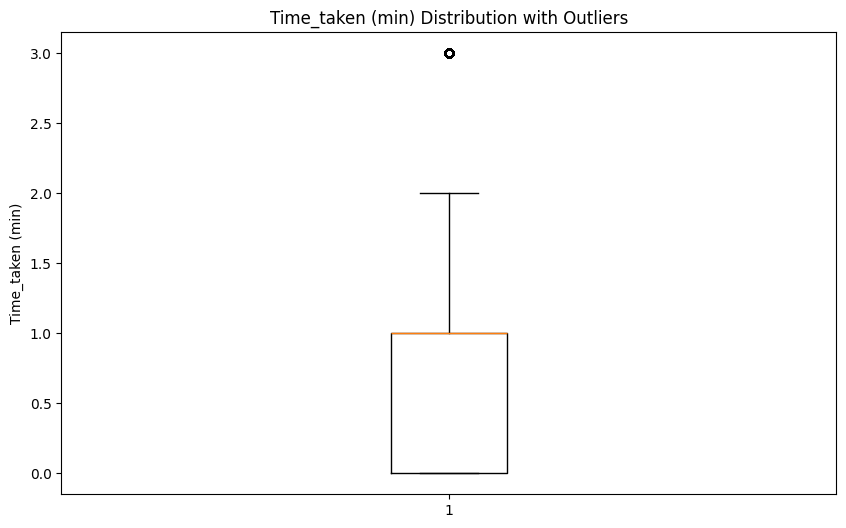

In [ ]:
# Visualize outliers
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.boxplot(df['multiple_deliveries'].dropna())
plt.title('Multiple Deliveries Distribution with Outliers')
plt.ylabel('Multiple Deliveries')
plt.show()

In [2]:
# 1 . basic data quality check

def check_data_quality(df):
    # Store initial data quality metrics
    quality_report = {
        'missing_values': df.isnull().sum().to_dict(),
        'duplicates': df.duplicated().sum(),
        'total_rows': len(df),
        'memory_usage': df.memory_usage().sum() / 1024**2  # in MB
    }
    return quality_report


In [ ]:
# 2 . standarddized data type

def standardize_datatypes(df):
    for column in df.columns:
        # Try converting string dates to datetime
        if df[column].dtype == 'object':
            try:
                df[column] = pd.to_datetime(df[column])
                print(f"Converted {column} to datetime")
            except ValueError:
                # Try converting to numeric if datetime fails
                try:
                    df[column] = pd.to_numeric(df[column].str.replace('$', '').str.replace(',', ''))
                    print(f"Converted {column} to numeric")
                except:
                    pass
    return df


In [ ]:
# 3 . handle missing value 

def handle_missing_values(df):
    # Handle numeric columns
    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
    if len(numeric_columns) > 0:
        num_imputer = SimpleImputer(strategy='median')
        df[numeric_columns] = num_imputer.fit_transform(df[numeric_columns])

    # Handle categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    if len(categorical_columns) > 0:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        df[categorical_columns] = cat_imputer.fit_transform(df[categorical_columns])

    return df

In [6]:
# 4. detect and handal outlier

def remove_outliers(df):
    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
    outliers_removed = {}

    for column in numeric_columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers before removing
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]

        # Cap the values instead of removing them
        df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

        if outliers > 0:
            outliers_removed[column] = outliers

    return df, outliers_removed


In [7]:
# 5 .  validate result

def validate_cleaning(df, original_shape, cleaning_report):
    validation_results = {
        'rows_remaining': len(df),
        'missing_values_remaining': df.isnull().sum().sum(),
        'duplicates_remaining': df.duplicated().sum(),
        'data_loss_percentage': (1 - len(df)/original_shape[0]) * 100
    }

    # Add validation results to the cleaning report
    cleaning_report['validation'] = validation_results
    return cleaning_report

In [11]:
# 6 . putting all together

def automated_cleaning_pipeline(df):
    # Store original shape for reporting
    original_shape = df.shape

    # Initialize cleaning report
    cleaning_report = {}

    # Execute each step and collect metrics
    cleaning_report['initial_quality'] = check_data_quality(df)

    df = standardize_datatypes(df)
    df = handle_missing_values(df)
    df, outliers = remove_outliers(df)
    cleaning_report['outliers_removed'] = outliers

    # Validate and finalize report
    cleaning_report = validate_cleaning(df, original_shape, cleaning_report)

    return df, cleaning_report

cleaned_df, report = automated_cleaning_pipeline(df=df)
print(cleaned_df.shape)
print(report)

C:\Users\Admin\AppData\Local\Temp\ipykernel_9812\1596907545.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column])
C:\Users\Admin\AppData\Local\Temp\ipykernel_9812\1596907545.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column])
C:\Users\Admin\AppData\Local\Temp\ipykernel_9812\1596907545.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column])
C:\Users\Admin\AppData\Local\Temp\ipykernel_9812\1596907545.py:8: UserWarning: Could not infer format, so each element will 

(45584, 20)
{'initial_quality': {'missing_values': {'ID': 0, 'Delivery_person_ID': 0, 'Delivery_person_Age': 1854, 'Delivery_person_Ratings': 1908, 'Restaurant_latitude': 0, 'Restaurant_longitude': 0, 'Delivery_location_latitude': 0, 'Delivery_location_longitude': 0, 'Order_Date': 0, 'Time_Orderd': 1731, 'Time_Order_picked': 0, 'Weather_conditions': 616, 'Road_traffic_density': 601, 'Vehicle_condition': 0, 'Type_of_order': 0, 'Type_of_vehicle': 0, 'multiple_deliveries': 993, 'Festival': 228, 'City': 1200, 'Time_taken (min)': 0}, 'duplicates': np.int64(0), 'total_rows': 45584, 'memory_usage': np.float64(6.955692291259766)}, 'outliers_removed': {'Delivery_person_Age': 53, 'Delivery_person_Ratings': 5345, 'Restaurant_latitude': 431, 'Restaurant_longitude': 4655, 'Delivery_location_longitude': 6515, 'multiple_deliveries': 361, 'Time_taken (min)': 270}, 'validation': {'rows_remaining': 45584, 'missing_values_remaining': np.int64(0), 'duplicates_remaining': np.int64(0), 'data_loss_percentage